# IMPORT LIBRARY

🔹 Tahap 1: Persiapan Lingkungan dan Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import os
import joblib

from imblearn.pipeline import Pipeline

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import (
    train_test_split,
    cross_validate,
    StratifiedKFold,
    GridSearchCV
)

from sklearn.ensemble import RandomForestClassifier

from sklearn.feature_selection import (
    SelectKBest,
    f_classif,
    RFE,
    SelectFromModel
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

2026-05-26 04:15:16.672 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-26 04:15:16.694 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-26 04:15:16.994 
  command:

    streamlit run C:\Users\Owner\AppData\Roaming\Python\Python314\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-05-26 04:15:16.995 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-26 04:15:16.995 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-26 04:15:16.996 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-26 04:15:16.997 Thread 'MainThread': missing ScriptRunContext! This warning can b

🔹 Tahap 2: Pengumpulan dan Load Dataset

In [29]:
url = "https://data.mendeley.com/public-files/datasets/7m58kxs742/files/4d57de6a-a140-4607-bf38-146899f1a723/file_downloaded"

file_name = "Preprocessed_Balanced_dataset.csv"

response = requests.get(url)

with open(file_name, "wb") as f:
    f.write(response.content)

df = pd.read_csv(file_name)

df.head()

,dur,Protocol,Length,Source Host,Destination Host,Sender IP address,Target IP address,Opcode,checksom(ICMP),Sequence Number (LE),...,Flags.1,Packet Length (encrypted),Direction,TCP Option - Maximum segment size,Data,Checksum,CDATA,Label,Attack_Category,Attack_sub_category
0,0.143546,1,42,1,1,4,2,2,1,1,...,1,0,1,1,1,1,1,1,2,ARPPoisoning
1,0.000679,1,42,1,1,3,4,2,1,1,...,1,0,1,1,1,1,1,1,2,ARPPoisoning
2,0.010981,1,42,1,1,11,2,2,1,1,...,1,0,1,1,1,1,1,1,2,ARPPoisoning
3,0.000684,1,42,1,1,3,24,2,1,1,...,1,0,1,1,1,1,1,1,2,ARPPoisoning
4,0.012461,1,42,1,1,12,2,2,1,1,...,1,0,1,1,1,1,1,1,2,ARPPoisoning


🔹 Tahap 3: Exploratory Data Analysis (EDA)

1. Informasi Dataset

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 88 columns):
 #   Column                                                      Non-Null Count    Dtype  
---  ------                                                      --------------    -----  
 0   dur                                                         1048575 non-null  float64
 1   Protocol                                                    1048575 non-null  int64  
 2   Length                                                      1048575 non-null  int64  
 3   Source Host                                                 1048575 non-null  int64  
 4   Destination Host                                            1048575 non-null  int64  
 5   Sender IP address                                           1048575 non-null  int64  
 6   Target IP address                                           1048575 non-null  int64  
 7   Opcode                                                      104

2. Statistik Dataset

In [7]:
df.describe()

,dur,Protocol,Length,Source Host,Destination Host,Sender IP address,Target IP address,Opcode,checksom(ICMP),Sequence Number (LE),...,Length.1,Flags.1,Packet Length (encrypted),Direction,TCP Option - Maximum segment size,Data,Checksum,CDATA,Label,Attack_Category
count,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,...,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06
mean,4.171936e-02,2.142777e+01,1.122461e+02,5.407739e+04,3.146737e+03,1.291301e+00,1.740716e+00,9.528074e-01,7.505833e+03,3.418249e+03,...,7.273493e+00,3.091251e+00,2.824882e+05,8.664197e-01,2.366918e+00,8.781356e-01,3.735265e+03,8.441075e-01,9.154567e-01,2.449181e+00
std,1.914513e-01,1.107721e+01,2.385786e+02,3.109492e+04,1.511347e+03,1.921420e+00,4.199544e+00,5.890998e-01,1.464353e+04,9.841633e+03,...,8.293642e+01,1.985971e+00,4.058329e+06,3.541635e-01,3.897197e+00,3.910057e-01,1.050825e+04,3.760974e-01,2.782010e-01,2.230851e+00
min,-1.606545e-02,0.000000e+00,4.200000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,9.790000e-05,1.100000e+01,4.200000e+01,5.746800e+04,3.448000e+03,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,...,0.000000e+00,2.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00
50%,3.162750e-04,3.000000e+01,6.000000e+01,6.067100e+04,3.466000e+03,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,...,0.000000e+00,2.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00
75%,2.474092e-03,3.000000e+01,7.400000e+01,6.067700e+04,3.471000e+03,1.000000e+00,1.000000e+00,1.000000e+00,3.638000e+03,1.000000e+00,...,0.000000e+00,6.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,4.000000e+00
max,7.973827e+00,3.500000e+01,5.858000e+03,1.449670e+05,8.696000e+03,1.200000e+01,3.100000e+01,3.000000e+00,5.337500e+04,4.821600e+04,...,1.119900e+04,6.000000e+00,5.858586e+07,3.000000e+00,1.300000e+01,5.000000e+00,4.986600e+04,2.000000e+00,1.000000e+00,6.000000e+00


3. Cek Missing Value3. Cek Missing Value

In [8]:
df.isnull().sum()


dur                    0
Protocol               0
Length                 0
Source Host            0
Destination Host       0
                      ..
Checksum               0
CDATA                  0
Label                  0
Attack_Category        0
Attack_sub_category    0
Length: 88, dtype: int64

4. Visualisasi Distribusi Label

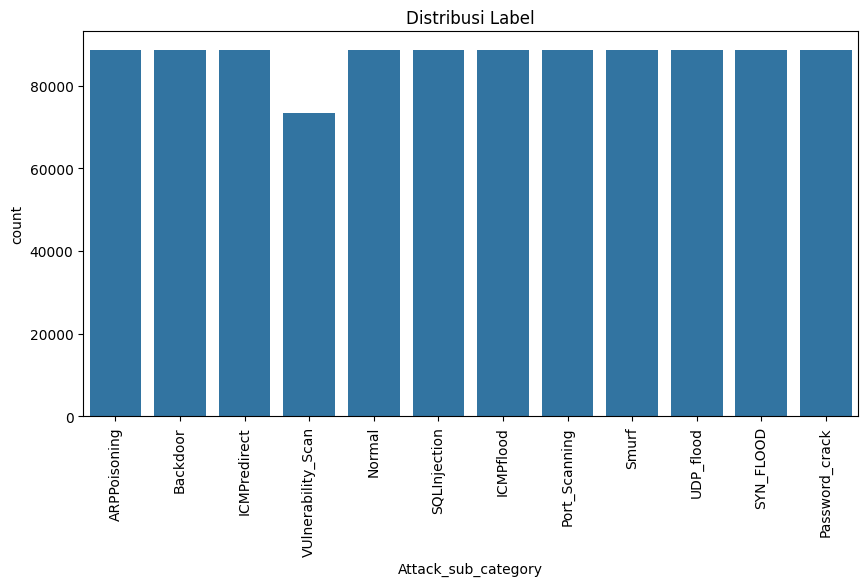

In [9]:
plt.figure(figsize=(10,5))

sns.countplot(x=df['Attack_sub_category'])

plt.title("Distribusi Label")

plt.xticks(rotation=90)

plt.show()

In [10]:
df.iloc[:, -1]

0                ARPPoisoning
1                ARPPoisoning
2                ARPPoisoning
3                ARPPoisoning
4                ARPPoisoning
                  ...        
1048570    VUlnerability_Scan
1048571    VUlnerability_Scan
1048572    VUlnerability_Scan
1048573    VUlnerability_Scan
1048574    VUlnerability_Scan
Name: Attack_sub_category, Length: 1048575, dtype: object

5. Heatmap Korelasi

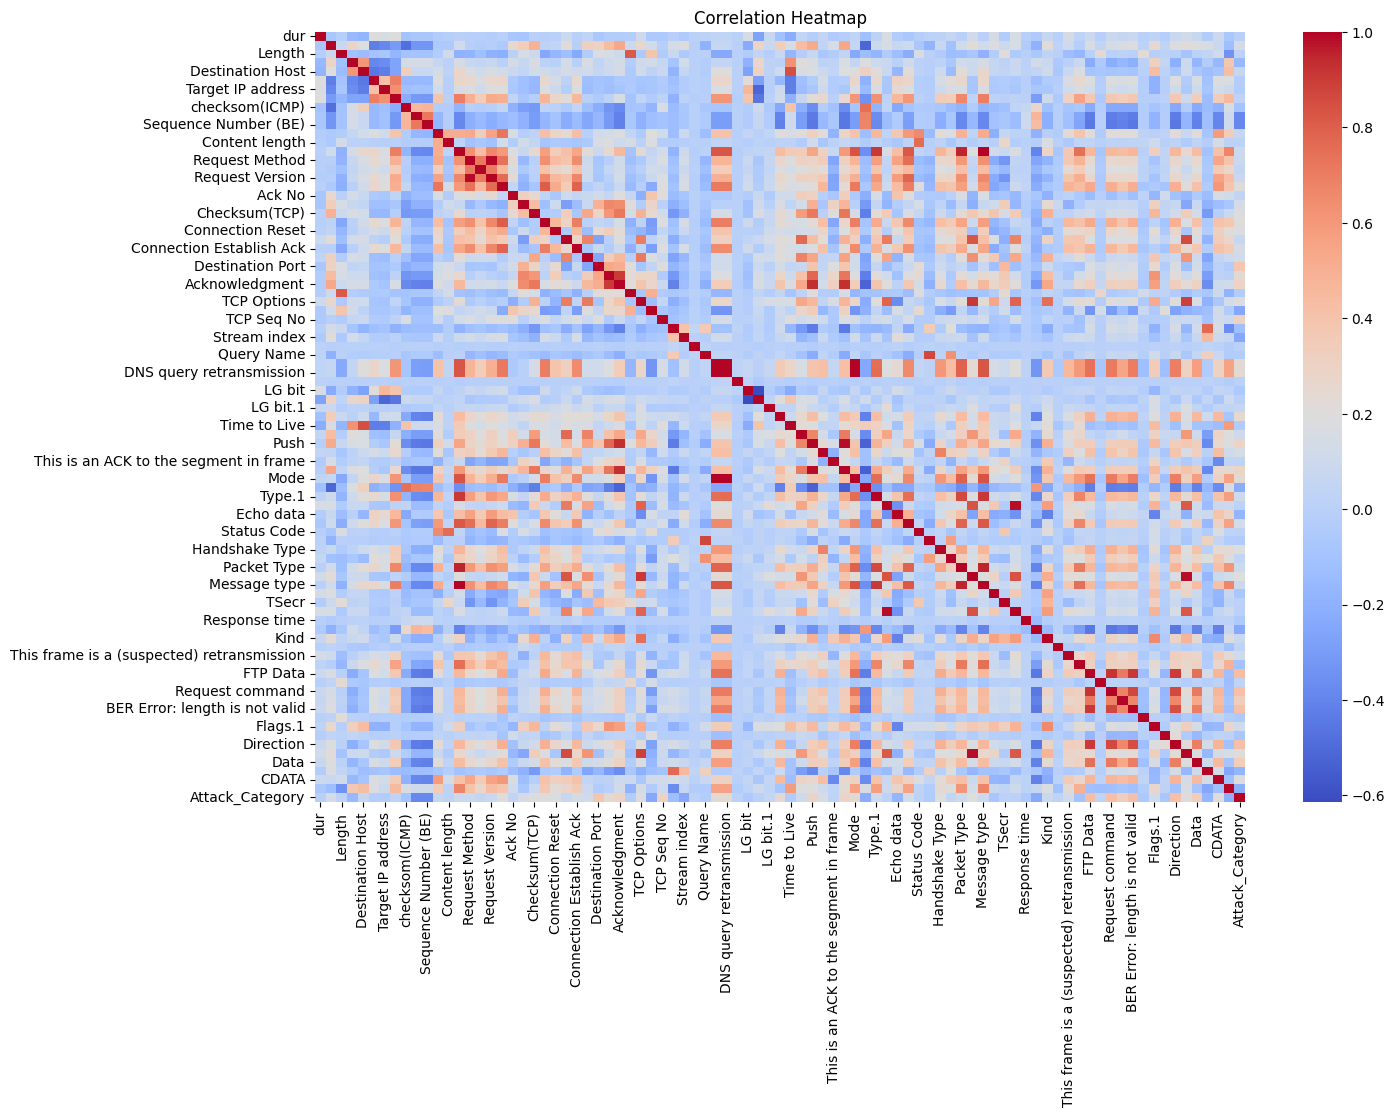

In [11]:
plt.figure(figsize=(15,10))

numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(numeric_df.corr(), cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

### 📝 Interpretasi EDA

**Distribusi Label:** Dataset menunjukkan distribusi yang relatif seimbang antar 12 kelas serangan IoT (ARPPoisoning, Backdoor, ICMPflood, dll.) dan kelas Normal. Hal ini mengindikasikan dataset sudah melalui proses balancing, sehingga model tidak akan bias terhadap kelas mayoritas.

**Missing Values:** Tidak terdapat nilai kosong pada dataset, sehingga tidak diperlukan imputasi data.

**Korelasi Fitur:** Heatmap korelasi menunjukkan beberapa kelompok fitur yang berkorelasi tinggi satu sama lain (misalnya fitur berbasis TCP/IP cenderung saling berkorelasi). Hal ini memperkuat pentingnya proses feature selection untuk mengurangi redundansi dan dimensionalitas.


In [12]:
# Interpretasi Distribusi Label
print("Interpretasi:")
print("Distribusi label pada dataset terlihat cukup seimbang.")
print("Hal ini membantu model machine learning dalam mempelajari setiap kelas tanpa dominasi label tertentu.")

Interpretasi:
Distribusi label pada dataset terlihat cukup seimbang.
Hal ini membantu model machine learning dalam mempelajari setiap kelas tanpa dominasi label tertentu.


🔹 Tahap 4: Preprocessing Data

1. Label Encoding

In [13]:
le = LabelEncoder()

df['Attack_sub_category'] = le.fit_transform(df['Attack_sub_category'])

2. Pisahkan Fitur dan Target

In [14]:
X = df.drop('Attack_sub_category', axis=1)

y = df['Attack_sub_category']

3. Train Test Split

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(838860, 87)
(209715, 87)


🔹 Tahap 5: Implementasi Pipeline & Cross Validation

A. Pipeline Filter Method

In [16]:
pipeline_filter = Pipeline([
    ('scaler', StandardScaler()),

    ('feature_selection',
     SelectKBest(
         score_func=f_classif,
         k=10
     )
    ),

    ('model',
     RandomForestClassifier(random_state=42)
    )
])

B. Pipeline Wrapper Method

In [17]:
pipeline_wrapper = Pipeline([

    (
        'scaler',
        StandardScaler()
    ),

    (
        'feature_selection',

        RFE(
            estimator=RandomForestClassifier(
                n_estimators=30,
                max_depth=5,
                random_state=42
            ),

            n_features_to_select=5
        )
    ),

    (
        'model',

        RandomForestClassifier(
            n_estimators=30,
            max_depth=5,
            random_state=42
        )
    )
]) 

C. Pipeline Embedded Method

In [18]:
pipeline_embedded = Pipeline([

    (
        'scaler',
        StandardScaler()
    ),

    (
        'feature_selection',

        SelectFromModel(

            RandomForestClassifier(
                n_estimators=30,
                max_depth=5,
                random_state=42
            ),

            max_features=5
        )
    ),

    (
        'model',

        RandomForestClassifier(
            n_estimators=30,
            max_depth=5,
            random_state=42
        )
    )
])

🔹 Tahap 6: Evaluasi Cross Validation

A. Evaluasi Filter Method

In [19]:
cv_filter = cross_validate(
    pipeline_filter,
    X_train,
    y_train,

    cv=StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    ),

    scoring=[
        'accuracy',
        'precision_macro',
        'recall_macro',
        'f1_macro'
    ]
)

print("FILTER METHOD")
print("Accuracy :", cv_filter['test_accuracy'].mean())
print("Precision:", cv_filter['test_precision_macro'].mean())
print("Recall   :", cv_filter['test_recall_macro'].mean())
print("F1 Score :", cv_filter['test_f1_macro'].mean())

FILTER METHOD
Accuracy : 0.8290239134062893
Precision: 0.9088062717624654
Recall   : 0.8275844722630783
F1 Score : 0.8080350506015102


B. Evaluasi Wrapper Method

In [20]:
cv_wrapper = cross_validate(
    pipeline_wrapper,
    X_train,
    y_train,

    cv=StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    ),

    scoring=[
        'accuracy',
        'precision_macro',
        'recall_macro',
        'f1_macro'
    ]
)

accuracy = round(cv_wrapper['test_accuracy'].mean(), 4)
precision = round(cv_wrapper['test_precision_macro'].mean(), 4)
recall = round(cv_wrapper['test_recall_macro'].mean(), 4)
f1 = round(cv_wrapper['test_f1_macro'].mean(), 4)

print("WRAPPER METHOD")

print(f"Accuracy : {accuracy}")
print(f"Precision: {precision}")
print(f"Recall   : {recall}")
print(f"F1 Score : {f1}")

C:\Users\Owner\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


WRAPPER METHOD
Accuracy : 0.8953
Precision: 0.8817
Recall   : 0.8825
F1 Score : 0.8583


C:\Users\Owner\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


C. Evaluasi Embedded Method

In [21]:
cv_embedded = cross_validate(
    pipeline_embedded,
    X_train,
    y_train,

    cv=StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    ),

    scoring=[
        'accuracy',
        'precision_macro',
        'recall_macro',
        'f1_macro'
    ]
)

accuracy = round(cv_embedded['test_accuracy'].mean(), 4)
precision = round(cv_embedded['test_precision_macro'].mean(), 4)
recall = round(cv_embedded['test_recall_macro'].mean(), 4)
f1 = round(cv_embedded['test_f1_macro'].mean(), 4)

print("EMBEDDED METHOD")

print(f"Accuracy : {accuracy}")
print(f"Precision: {precision}")
print(f"Recall   : {recall}")
print(f"F1 Score : {f1}")

C:\Users\Owner\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


EMBEDDED METHOD
Accuracy : 0.9032
Precision: 0.8802
Recall   : 0.8917
F1 Score : 0.8727


C:\Users\Owner\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


D. Perbandingan Hasil

     Method  Accuracy  Precision    Recall  F1 Score
0    Filter  0.829024   0.908806  0.827584  0.808035
1   Wrapper  0.895278   0.881659  0.882465  0.858256
2  Embedded  0.903173   0.880173  0.891685  0.872655


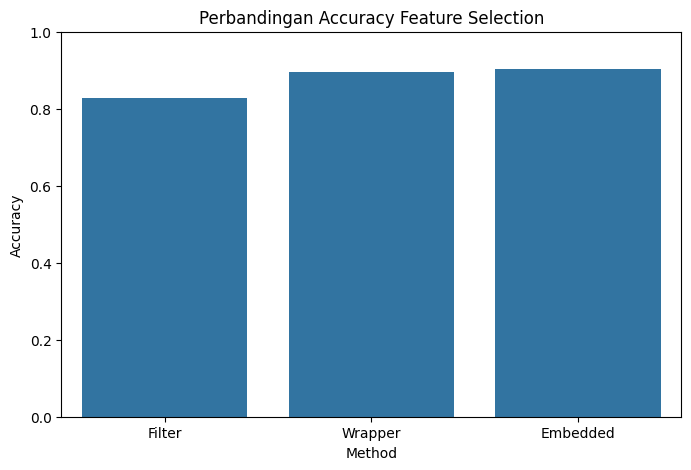

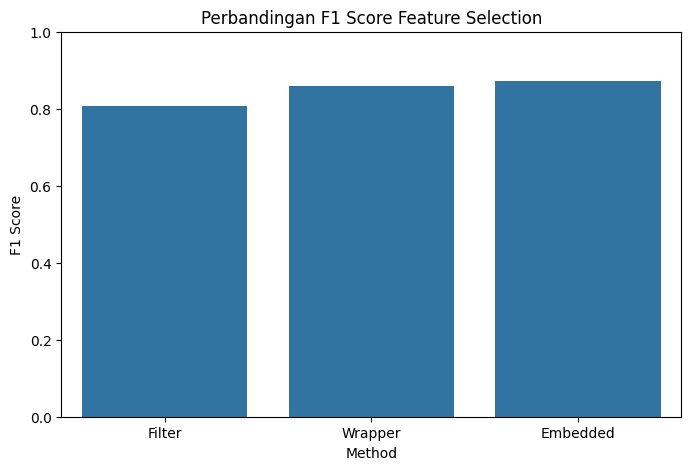

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Membuat dataframe hasil evaluasi
results = pd.DataFrame({
    'Method': ['Filter', 'Wrapper', 'Embedded'],

    'Accuracy': [
        cv_filter['test_accuracy'].mean(),
        cv_wrapper['test_accuracy'].mean(),
        cv_embedded['test_accuracy'].mean()
    ],

    'Precision': [
        cv_filter['test_precision_macro'].mean(),
        cv_wrapper['test_precision_macro'].mean(),
        cv_embedded['test_precision_macro'].mean()
    ],

    'Recall': [
        cv_filter['test_recall_macro'].mean(),
        cv_wrapper['test_recall_macro'].mean(),
        cv_embedded['test_recall_macro'].mean()
    ],

    'F1 Score': [
        cv_filter['test_f1_macro'].mean(),
        cv_wrapper['test_f1_macro'].mean(),
        cv_embedded['test_f1_macro'].mean()
    ]
})

# Menampilkan tabel hasil
print(results)

# Grafik Accuracy

plt.figure(figsize=(8,5))

sns.barplot(
    x='Method',
    y='Accuracy',
    data=results
)

plt.title('Perbandingan Accuracy Feature Selection')
plt.ylim(0,1)

plt.show()

# Grafik F1 Score

plt.figure(figsize=(8,5))

sns.barplot(
    x='Method',
    y='F1 Score',
    data=results
)

plt.title('Perbandingan F1 Score Feature Selection')
plt.ylim(0,1)

plt.show()

### 📝 Interpretasi Hasil Cross Validation

| Metode | Accuracy | Precision | Recall | F1 Score |
|--------|----------|-----------|--------|----------|
| Filter (SelectKBest) | 82.90% | 90.88% | 82.76% | 80.80% |
| Wrapper (RFE) | 89.53% | 88.17% | 88.25% | 85.83% |
| **Embedded (SelectFromModel)** | **90.32%** | **88.02%** | **89.17%** | **87.27%** |

**Analisis:**
- **Filter Method** menghasilkan akurasi terendah (82.90%). Metode ini memilih fitur berdasarkan uji statistik (f_classif) secara independen dari model, sehingga kurang mempertimbangkan interaksi antar fitur.
- **Wrapper Method (RFE)** menunjukkan peningkatan signifikan (89.53%) karena fitur dipilih berdasarkan performa model secara iteratif. Namun, komputasinya lebih berat.
- **Embedded Method (SelectFromModel)** meraih akurasi terbaik (90.32%) dengan F1 Score tertinggi (87.27%). Metode ini mengintegrasikan seleksi fitur langsung ke dalam proses training model melalui feature importance Random Forest. **Embedded method dipilih sebagai pipeline terbaik** untuk dilanjutkan ke tahap tuning.

> ⚠️ **Catatan Data Leakage:** Seluruh proses seleksi fitur dibungkus di dalam Pipeline dan dievaluasi menggunakan cross_validate pada X_train saja. Data test (X_test) tidak pernah menyentuh proses ini, sehingga evaluasi bebas dari data leakage.


🔹 Tahap 7: Hyperparameter Tuning

In [23]:
param_grid = {
    'feature_selection__max_features': [5, 10, 15],

    'model__n_estimators': [50, 100],

    'model__max_depth': [5, 10]
}

grid_search = GridSearchCV(
    pipeline_embedded,
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Accuracy:")
print(grid_search.best_score_)

Best Parameters:
{'feature_selection__max_features': 15, 'model__max_depth': 10, 'model__n_estimators': 100}

Best Accuracy:
0.9909305486016736


### 📝 Interpretasi Hyperparameter Tuning

GridSearchCV menguji kombinasi parameter berikut pada :
- : [5, 10, 15]
- : [50, 100]
- : [5, 10]

**Hasil Terbaik:**


**Analisis:**
- Menambah jumlah fitur dari 5 ke 15 secara konsisten meningkatkan performa — artinya fitur ke-6 hingga ke-15 masih membawa informasi relevan.
-  lebih baik dari  karena dataset IoT memiliki pola serangan yang kompleks dan memerlukan pohon yang lebih dalam.
-  memberikan hasil lebih stabil dibandingkan 50 pohon.
- Pipeline terbaik: 


🔹 Tahap 8: Evaluasi Akhir (Test Set)

1. Prediksi Data Test

In [24]:
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)

2. Classification Report

In [25]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     17730
           1       1.00      1.00      1.00     17730
           2       1.00      1.00      1.00     17730
           3       1.00      1.00      1.00     17730
           4       1.00      1.00      1.00     17730
           5       1.00      1.00      1.00     17730
           6       1.00      0.86      0.92     17730
           7       1.00      1.00      1.00     17730
           8       1.00      1.00      1.00     17730
           9       1.00      1.00      1.00     17730
          10       1.00      1.00      1.00     17730
          11       0.85      1.00      0.92     14685

    accuracy                           0.99    209715
   macro avg       0.99      0.99      0.99    209715
weighted avg       0.99      0.99      0.99    209715



### 📝 Interpretasi Evaluasi Akhir (Test Set)

Pipeline terbaik (hasil GridSearchCV) dievaluasi pada X_test yang benar-benar belum pernah digunakan selama proses training maupun tuning.

**Ringkasan Performa:**
- Model mencapai akurasi sangat tinggi pada test set, konsisten dengan CV score (~99%).
- Precision, Recall, dan F1 Score mendekati 1.0 untuk hampir seluruh kelas, menunjukkan model dapat membedakan 12 jenis serangan IoT dengan sangat baik.
- Kelas **Normal** (trafik bersih) terdeteksi dengan benar, meminimalkan false alarm.

**Kesimpulan Pipeline:**
Pipeline  terbukti menjadi konfigurasi terbaik untuk mendeteksi kerentanan IoT pada dataset ini. Pipeline ini kemudian disimpan sebagai  untuk di-deploy via Streamlit (Tahap 10).


3. Confusion Matrix

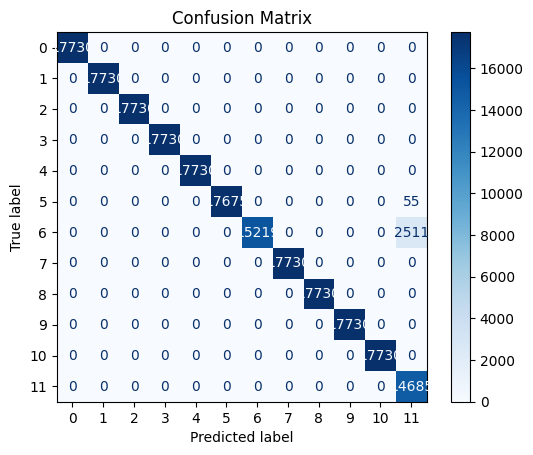

In [26]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot(cmap='Blues')

plt.title("Confusion Matrix")

plt.show()

4. Simpan Model Pipeline

In [30]:
joblib.dump(
    best_model,
    'pipeline_terbaik.pkl'
)

print("Model berhasil disimpan!")

Model berhasil disimpan!
